In [79]:
import pandas as pd
import re
import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score

career_df = pd.read_csv("cleaned_career_recomendation.csv")
career_df.head()

top_jobs = career_df['first_job_title'].value_counts().head(10).index

career_df = career_df[
    career_df['first_job_title'].isin(top_jobs)
].copy()

career_df['first_job_title'].value_counts()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

career_df['clean_skills'] = career_df['skills'].apply(clean_text)

career_df[['skills', 'clean_skills', 'first_job_title']].head()

tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(career_df['clean_skills'])

encoder = LabelEncoder()
y = encoder.fit_transform(career_df['first_job_title'])

num_classes = len(encoder.classes_)

print("Number of classes:", num_classes)
print(encoder.classes_)

Number of classes: 10
['Business Analyst' 'Civil & Structural Engineer'
 'Computer Software Engineer' 'Data Analyst' 'Mechanical Engineer'
 'Sales Executive' 'Software Engineer' 'Student (Unemployed)' 'Teacher'
 'not applicable']


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (436, 153)
X_test: (110, 153)
y_train: (436,)
y_test: (110,)


In [70]:
X_train_array = X_train.toarray()
X_test_array = X_test.toarray()

In [71]:
input_dim = X_train_array.shape[1]

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [72]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [73]:
history = model.fit(
    X_train_array,
    y_train,
    validation_data=(X_test_array, y_test),
    epochs=20,
    batch_size=32
)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4243 - loss: 2.1880 - val_accuracy: 0.5545 - val_loss: 2.0448
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5413 - loss: 1.8618 - val_accuracy: 0.5455 - val_loss: 1.6391
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5413 - loss: 1.4760 - val_accuracy: 0.5455 - val_loss: 1.3513
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5413 - loss: 1.3118 - val_accuracy: 0.6000 - val_loss: 1.2507
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6147 - loss: 1.2175 - val_accuracy: 0.6727 - val_loss: 1.1782
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6514 - loss: 1.1535 - val_accuracy: 0.7182 - val_loss: 1.1103
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6858 - loss: 1.0837 - val_accuracy: 0.7273 - val_loss: 1.0635
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6858 - loss: 1.0353 - val_accuracy: 0.7545 - val_los

In [74]:
loss, accuracy = model.evaluate(X_test_array, y_test)

print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7636 - loss: 0.8875
Test Accuracy: 0.7636363506317139


In [75]:
y_pred_prob = model.predict(X_test_array)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
                             precision    recall  f1-score   support

           Business Analyst       0.00      0.00      0.00         4
Civil & Structural Engineer       1.00      1.00      1.00         3
 Computer Software Engineer       0.50      0.17      0.25         6
               Data Analyst       0.00      0.00      0.00         3
        Mechanical Engineer       0.00      0.00      0.00         4
            Sales Executive       0.00      0.00      0.00         2
          Software Engineer       0.00      0.00      0.00         2
       Student (Unemployed)       0.54      0.91      0.68        23
                    Teacher       0.00      0.00      0.00         3
             not applicable       0.89      0.98      0.94        60

                   accuracy                           0.76       110
                  macro avg       0.29      0.31      0.29       110
               weighted avg       0.65      0.76      0.69     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
import joblib

model.save("career_recommendation_model.keras")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [78]:
model.save("career_recommendation_model.keras")

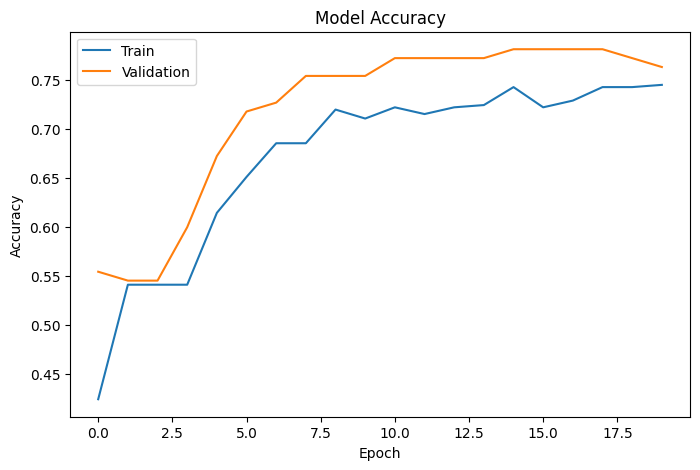

In [80]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

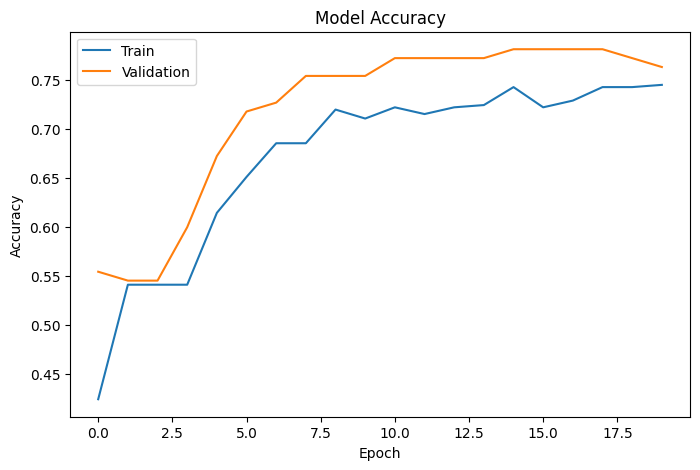

In [81]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [82]:
sample_skill = ["python sql machine learning"]

sample_vector = tfidf.transform(sample_skill).toarray()

prediction = model.predict(sample_vector)

predicted_label = np.argmax(prediction, axis=1)

predicted_job = encoder.inverse_transform(predicted_label)

print("Predicted Job:", predicted_job[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted Job: not applicable


## Kesimpulan Baseline Modeling

Model baseline berhasil dikembangkan menggunakan TensorFlow untuk memprediksi pekerjaan berdasarkan skill pengguna. Data teks diproses menggunakan TF-IDF, sedangkan label pekerjaan dikonversi menggunakan LabelEncoder.

Hasil evaluasi menunjukkan bahwa model sudah mampu melakukan klasifikasi pekerjaan dasar dan dapat digunakan sebagai fondasi untuk pengembangan sistem recommendation pada tahap selanjutnya.